In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime


In [2]:
df = pd.read_csv("../data/cleaned_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8


In [3]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date


Timestamp('2011-12-10 12:50:00')

In [4]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "InvoiceNo": "nunique",                                   # Frequency
    "TotalPrice": "sum"                                       # Monetary
}).reset_index()


In [5]:
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [6]:
rfm.describe()


,CustomerID,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,92.518322,4.271952,2053.793018
std,1721.889758,100.009747,7.705493,8988.248381
min,12346.000000,1.000000,1.000000,0.000000
25%,13812.500000,18.000000,1.000000,307.245000
50%,15299.000000,51.000000,2.000000,674.450000
75%,16778.500000,142.000000,5.000000,1661.640000
max,18287.000000,374.000000,210.000000,280206.020000


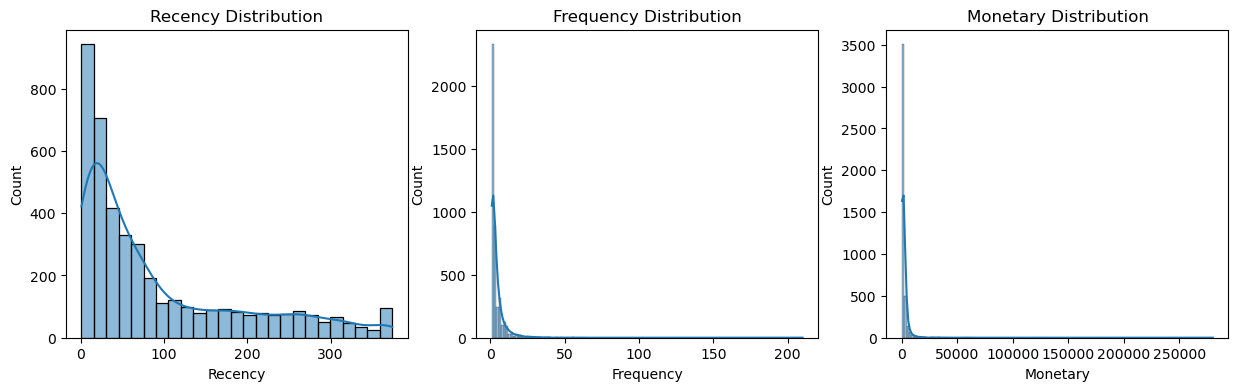

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(rfm["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.show()


In [8]:
rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

rfm_log.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,5.789960,0.693147,11.253955
1,12347.0,1.098612,2.079442,8.368925
2,12348.0,4.330733,1.609438,7.494564
3,12349.0,2.995732,0.693147,7.472245
4,12350.0,5.739793,0.693147,5.815324


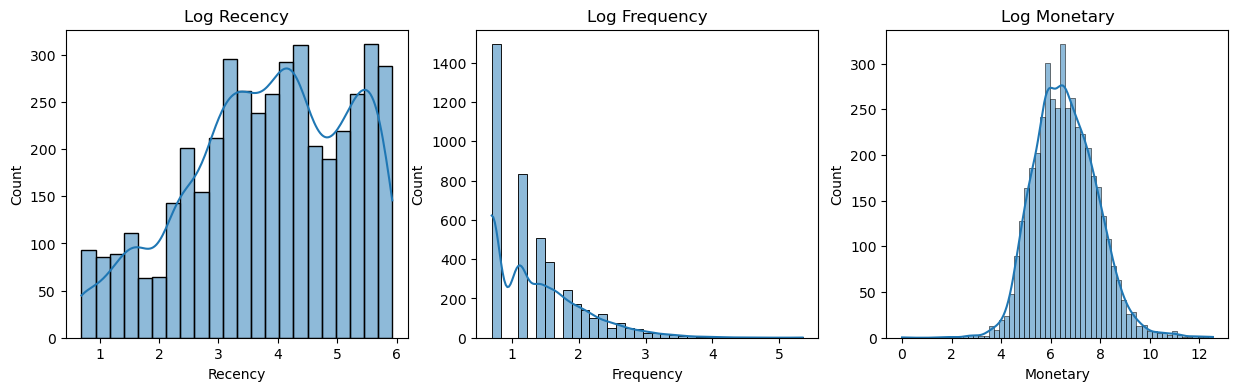

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(rfm_log["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Log Recency")

sns.histplot(rfm_log["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Log Frequency")

sns.histplot(rfm_log["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Log Monetary")

plt.show()


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_log[["Recency", "Frequency", "Monetary"]]
)

rfm_scaled[:5]


array([[ 1.46223615, -0.95501313,  3.69616759],
       [-2.03861142,  1.07452296,  1.40875812],
       [ 0.37331015,  0.38643726,  0.71551656],
       [-0.62291426, -0.95501313,  0.69782099],
       [ 1.42479959, -0.95501313, -0.61587654]])

In [11]:
rfm_features = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

rfm_features["CustomerID"] = rfm["CustomerID"].values

rfm_features.head()


,Recency,Frequency,Monetary,CustomerID
0,1.462236,-0.955013,3.696168,12346.0
1,-2.038611,1.074523,1.408758,12347.0
2,0.373310,0.386437,0.715517,12348.0
3,-0.622914,-0.955013,0.697821,12349.0
4,1.424800,-0.955013,-0.615877,12350.0


In [12]:
rfm.to_csv("../data/rfm_raw.csv", index=False)
rfm_features.to_csv("../data/rfm_features.csv", index=False)

print("✅ RFM feature files saved successfully")


✅ RFM feature files saved successfully


In [13]:
import joblib

joblib.dump(scaler, "../models/rfm_scaler.pkl")

print("✅ RFM scaler saved")


✅ RFM scaler saved
